# Showcase — Gaza, satellite change detection (Khan Younis, 2023 → 2024)

Before/after satellite imagery is a standard humanitarian damage-assessment tool. This notebook pulls a two-year Sentinel-2 time series over **Khan Younis** (southern Gaza) through the Google Earth Engine backend, reads each series straight off disk with pyramids' `DatasetCollection.read_multiple_files()`, renders the scenes in **true colour** with `Dataset.plot(rgb_options=...)`, and animates the derived **NDVI** with the collection's own `save_animation()`. Presented factually; no interpretation beyond what the pixels show.

## What this notebook does

1. **Download** a seven-date Sentinel-2 series — true-colour bands `B4,B3,B2` and the NIR/red pair `B8,B4` — into two folders, computing an NDVI raster per date.
2. **Read each folder as a collection** with `DatasetCollection.read_multiple_files()` (no manual file lists).
3. **True-colour progression** — every date rendered as an RGB composite with `Dataset.plot(rgb_options=...)`.
4. **Animated true colour** — the same scenes as a real-colour GIF.
5. **NDVI before / after / change** maps with `Dataset.plot()`.
6. **Animated NDVI** across the seven dates with `DatasetCollection.plot().save_animation()`.
7. **NDVI timeline** (matplotlib chart).

NDVI = (NIR − Red)/(NIR + Red): high over vegetation, near zero over bare ground.

> Needs `GEE_SERVICE_ACCOUNT` / `GEE_SERVICE_KEY` and `pyramids-gis[viz]`.

## Setup

First the imports and a bit of noise-suppression. `pyramids` provides `Dataset` and `DatasetCollection` (reading + plotting); `earthlens` provides the unified `EarthLens` entry point.

In [1]:
import os
import shutil
import tempfile
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from loguru import logger
from pyramids.dataset import Dataset, DatasetCollection  # pyramids' own IO + plotting

from earthlens import EarthLens

warnings.filterwarnings("ignore")
logger.remove()  # silence earthlens / pyramids / GDAL log chatter
plt.rcParams["figure.dpi"] = 80  # keep embedded outputs lean

2026-06-13 17:57:03 | INFO | pyramids.base.config | Logging is configured.


### Credentials

The notebook reads its credentials from a `.env` file at the repository root (loaded with `python-dotenv`; your `PATH` is left untouched). Create that `.env` with:

```text
GEE_SERVICE_ACCOUNT="your-sa@your-project.iam.gserviceaccount.com"
GEE_SERVICE_KEY="/path/to/your/service-account-key.json"
```

In [2]:
from dotenv import find_dotenv, load_dotenv

load_dotenv(find_dotenv(usecwd=True))

SERVICE_ACCOUNT = os.environ["GEE_SERVICE_ACCOUNT"]  # Earth Engine service-account email
SERVICE_KEY = os.environ["GEE_SERVICE_KEY"]  # path to the service-account JSON key
if any(x is None for x in (SERVICE_ACCOUNT, SERVICE_KEY)):
    raise ValueError("Missing credentials in .env")

## 1 · Download the Sentinel-2 series

### Request parameters

The AOI is a small lon/lat box over Khan Younis, and `DATES` is the seven Sentinel-2 acquisition dates spanning 2023–2024. We also create the two scratch folders that the downloaded true-colour and derived NDVI rasters land in.

In [3]:
AOI = [34.28, 31.32, 34.33, 31.37]  # Khan Younis, southern Gaza (lon/lat box)
COLL = "COPERNICUS/S2_SR_HARMONIZED"
DATES = [
    "2023-01-15",
    "2023-05-15",
    "2023-09-12",
    "2023-12-11",
    "2024-03-10",
    "2024-05-09",
    "2024-09-11",
]
rgb_dir, ndvi_dir = tempfile.mkdtemp(), tempfile.mkdtemp()

### Helpers for one date

`fetch_band_tif()` builds a GEE request for one date and band set, authenticates, downloads the single composite, and returns the written file path. The construct → `authenticate` → `download` steps are kept on separate lines. `ndvi_from_nir()` turns the downloaded NIR/red pair into an NDVI raster on disk, reusing the source geotransform/EPSG so the result stays georeferenced.

In [4]:
def fetch_band_tif(date, variables):
    """Download one Sentinel-2 composite for `date` over AOI; return the written file path."""
    scene = EarthLens(
        data_source="gee",
        cadence="raw",
        path=tempfile.mkdtemp(),
        dataset=COLL,
        variables=variables,
        aoi=AOI,
        start=date,
        end=date,
        scale=10,
        reducer="median",
    )
    scene.authenticate(service_account=SERVICE_ACCOUNT, service_key=SERVICE_KEY)
    paths = scene.download(progress_bar=False)
    return str(paths[0])


def ndvi_from_nir(nir_path):
    """Compute NDVI = (NIR - Red)/(NIR + Red) from a B8,B4 raster; return (ndvi_array, source)."""
    src = Dataset.read_file(nir_path)
    a = np.asarray(src.read_array(), dtype="float32")
    ndvi = (a[0] - a[1]) / (a[0] + a[1] + 1e-6)
    return ndvi, src

### Download every date

For each date we fetch the true-colour composite (`B4,B3,B2`) and the NIR/red pair (`B8,B4`), copy the true-colour scene into `rgb_dir`, derive the NDVI raster, and persist it into `ndvi_dir`. The download and index-into-result are split onto their own lines per call.

In [5]:
dates = []
for d in DATES:
    rgb = fetch_band_tif(d, ["B4", "B3", "B2"])  # true-colour scene
    nir = fetch_band_tif(d, ["B8", "B4"])  # NIR/red pair for NDVI
    if not (rgb and nir):
        continue
    tag = d.replace("-", ".")
    shutil.copy(rgb, os.path.join(rgb_dir, f"rgb_{tag}.tif"))
    ndvi, src = ndvi_from_nir(nir)
    out = Dataset.create_from_array(arr=ndvi[None, :, :], geo=src.geotransform, epsg=src.epsg)
    out.to_file(os.path.join(ndvi_dir, f"ndvi_{tag}.tif"))  # persist derived NDVI
    dates.append(d)

print(f"{len(dates)} scenes:", dates)

2026-06-13 17:57:26 | WARNING | pyramids.base.config.gdal | GDAL[1] 1781366246648310600_885240.tif: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


2026-06-13 17:57:26 | WARNING | pyramids.base.config.gdal | GDAL[1] TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


2026-06-13 17:57:42 | WARNING | pyramids.base.config.gdal | GDAL[1] 1781366262567899500_586582.tif: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


2026-06-13 17:57:42 | WARNING | pyramids.base.config.gdal | GDAL[1] TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


2026-06-13 17:58:01 | WARNING | pyramids.base.config.gdal | GDAL[1] 1781366281365936900_95343.tif: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


...

2026-06-13 17:58:56 | WARNING | pyramids.base.config.gdal | GDAL[1] 1781366336481076100_409027.tif: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


2026-06-13 17:58:56 | WARNING | pyramids.base.config.gdal | GDAL[1] TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


2026-06-13 17:59:17 | WARNING | pyramids.base.config.gdal | GDAL[1] 1781366357097794800_76068.tif: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


2026-06-13 17:59:17 | WARNING | pyramids.base.config.gdal | GDAL[1] TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


7 scenes: ['2023-01-15', '2023-05-15', '2023-09-12', '2023-12-11', '2024-03-10', '2024-05-09', '2024-09-11']


### Read each folder as a collection

`DatasetCollection.read_multiple_files()` reads a whole directory in one call — no manual file lists. We build one collection for the true-colour scenes and one for the derived NDVI rasters.

In [6]:
dc_rgb = DatasetCollection.read_multiple_files(rgb_dir, date=False) if dates else None
dc_ndvi = DatasetCollection.read_multiple_files(ndvi_dir, date=False) if dates else None

## 2 · True-colour progression — `Dataset.plot(rgb_options=...)`

Each date is rendered as a real-colour RGB composite (`B4,B3,B2`), 2–98th-percentile stretched.

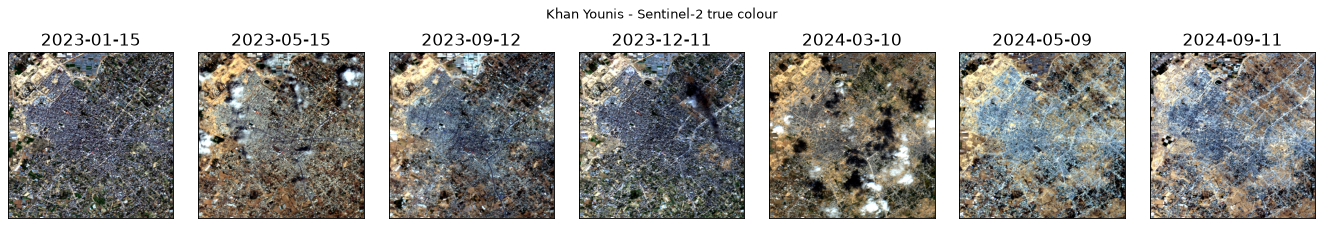

In [7]:
if dc_rgb:
    n = dc_rgb.time_length
    fig, ax = plt.subplots(1, n, figsize=(2.4 * n, 2.7))
    for i, d in enumerate(dates):
        dc_rgb.iloc(i).plot(
            rgb_options={"rgb": [0, 1, 2], "percentile": 2}, ax=ax[i], title=d
        )
        ax[i].set_xticks([])
        ax[i].set_yticks([])
    fig.suptitle("Khan Younis - Sentinel-2 true colour", y=1.03)
    plt.tight_layout()
    plt.show()
else:
    print("no scenes - set GEE_SERVICE_ACCOUNT / GEE_SERVICE_KEY and rerun")

## 3 · Before / after — true colour

The first and last scenes side by side at full size.

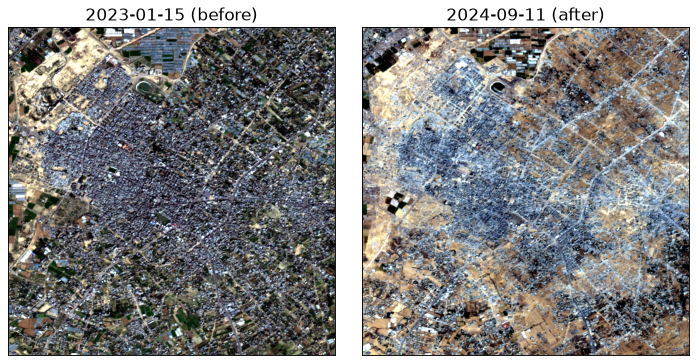

In [8]:
if dc_rgb:
    fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
    dc_rgb.iloc(0).plot(
        rgb_options={"rgb": [0, 1, 2], "percentile": 2},
        ax=ax[0],
        title=f"{dates[0]} (before)",
    )
    dc_rgb.iloc(dc_rgb.time_length - 1).plot(
        rgb_options={"rgb": [0, 1, 2], "percentile": 2},
        ax=ax[1],
        title=f"{dates[-1]} (after)",
    )
    for a in ax:
        a.set_xticks([])
        a.set_yticks([])
    plt.tight_layout()
    plt.show()

## 4 · Animated true colour

The seven scenes as a real-colour animation. `DatasetCollection.plot()` animates a single band, so each RGB frame is prepared with cleopatra's `ArrayGlyph.prepare_array` (the same percentile stretch `Dataset.plot(rgb_options=...)` applies) and the frames are stepped into a GIF.

First build the percentile-stretched RGB frames — one per scene — with cleopatra's `prepare_array`, the exact stretch `Dataset.plot`'s RGB path uses.

In [9]:
from cleopatra.array_glyph import ArrayGlyph
from matplotlib.animation import FuncAnimation, PillowWriter

frames = None
if dc_rgb:
    helper = ArrayGlyph(np.zeros((1, 1)))  # bare glyph: only its prepare_array is used
    frames = [
        helper.prepare_array(
            np.asarray(dc_rgb.iloc(i).read_array(), dtype="float32")[:3],
            rgb=[0, 1, 2],
            percentile=2,
        )
        for i in range(dc_rgb.time_length)
    ]

Then step the prepared frames into a GIF with matplotlib and display it.

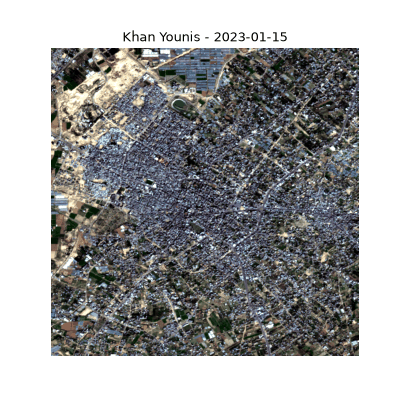

In [10]:
def _step(i):
    im.set_data(frames[i])
    ax.set_title(f"Khan Younis - {dates[i]}")
    return [im]


if frames:
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(frames[0])
    ax.axis("off")
    anim = FuncAnimation(fig, _step, frames=len(frames), interval=800)
    gif = os.path.join(tempfile.mkdtemp(), "true_colour.gif")
    anim.save(gif, writer=PillowWriter(fps=1.2))
    plt.close(fig)
    display(Image(filename=gif))
else:
    print("no scenes to animate")

## 5 · NDVI before / after / change — `Dataset.plot()`

NDVI is a single-band index, so it is rendered with a colour map rather than as an RGB composite. We pull the May 2023 and May 2024 NDVI arrays and difference them.

In [11]:
if dc_ndvi:
    i_b, i_a = dates.index("2023-05-15"), dates.index("2024-05-09")
    nd_b = dc_ndvi.iloc(i_b).read_array(band=0)
    nd_a = dc_ndvi.iloc(i_a).read_array(band=0)

Render the before, after, and change maps side by side: the two dates with a green colour map and the 2024−2023 difference with a diverging one.

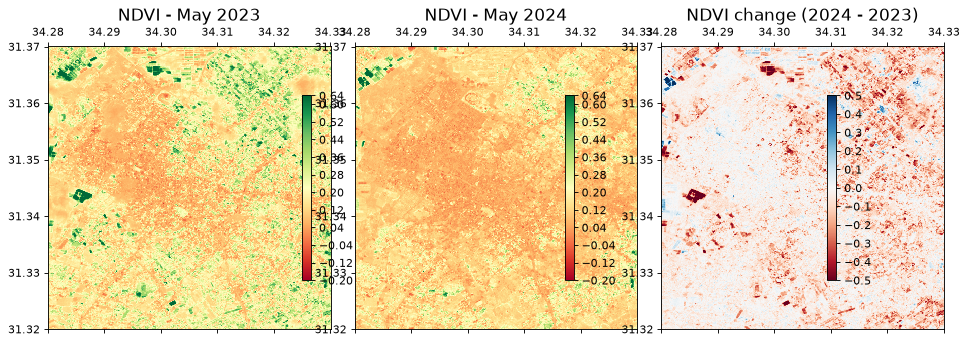

In [12]:
if dc_ndvi:
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    dc_ndvi.iloc(i_b).plot(
        band=0, ax=ax[0], cmap="RdYlGn", title="NDVI - May 2023", vmin=-0.2, vmax=0.6
    )
    dc_ndvi.iloc(i_a).plot(
        band=0, ax=ax[1], cmap="RdYlGn", title="NDVI - May 2024", vmin=-0.2, vmax=0.6
    )
    diff = Dataset.create_from_array(
        arr=(nd_a - nd_b)[None, :, :],
        geo=dc_ndvi.iloc(0).geotransform,
        epsg=dc_ndvi.iloc(0).epsg,
    )
    diff.plot(
        band=0,
        ax=ax[2],
        cmap="RdBu",
        title="NDVI change (2024 - 2023)",
        vmin=-0.5,
        vmax=0.5,
    )
    plt.tight_layout()
    plt.show()

Summarise the shift: mean NDVI and the vegetated fraction (NDVI > 0.3) before vs after.

In [13]:
if dc_ndvi:
    veg = lambda x: float(np.mean(x > 0.3))
    print(
        f"mean NDVI 2023 {np.nanmean(nd_b):.3f} -> 2024 {np.nanmean(nd_a):.3f}; "
        f"vegetated {veg(nd_b):.1%} -> {veg(nd_a):.1%}"
    )

mean NDVI 2023 0.181 -> 2024 0.119; vegetated 13.4% -> 2.7%


## 6 · Animated NDVI — `DatasetCollection.plot().save_animation()`

The collection animates one band across all seven dates; NDVI is the natural single-band quantity to watch. The `plot()` call and `save_animation()` are split onto their own lines.

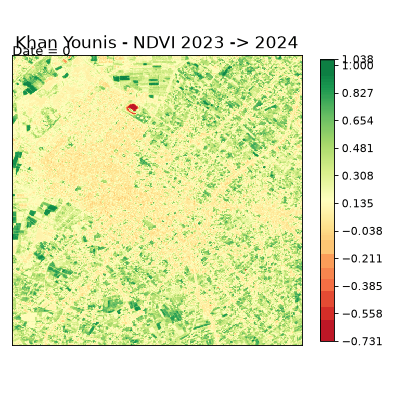

In [14]:
if dc_ndvi:
    gif = os.path.join(tempfile.mkdtemp(), "ndvi.gif")
    glyph = dc_ndvi.plot(
        band=0,
        cmap="RdYlGn",
        figsize=(5, 5),
        title="Khan Younis - NDVI 2023 -> 2024",
    )
    glyph.save_animation(gif, fps=1.2)
    plt.close("all")  # drop the static builder frame; keep only the GIF
    display(Image(filename=gif))

## 7 · NDVI timeline across all seven dates

Mean NDVI per date as a line chart, with a dashed reference line at the 0.3 vegetated threshold.

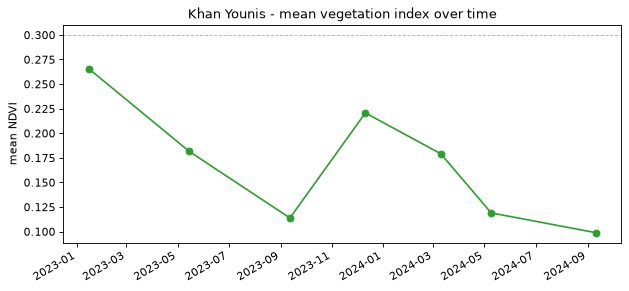

In [15]:
if dc_ndvi:
    series_v = [
        float(np.nanmean(dc_ndvi.iloc(i).read_array(band=0)))
        for i in range(dc_ndvi.time_length)
    ]
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot([pd.Timestamp(d) for d in dates], series_v, "-o", color="tab:green")
    ax.axhline(0.3, color="0.7", ls="--", lw=0.8)
    ax.set(ylabel="mean NDVI", title="Khan Younis - mean vegetation index over time")
    fig.autofmt_xdate()
    plt.show()

## Recap

Both series are read from disk with `DatasetCollection.read_multiple_files()`. The progression and before/after panels render in **true colour** with `Dataset.plot(rgb_options=...)`, and the same scenes animate as a real-colour GIF (frames prepared by cleopatra's `prepare_array`). The NDVI maps use `Dataset.plot()` with a colour map (an index is single-band by nature); the NDVI animation comes straight from `DatasetCollection.plot().save_animation()`.

## Try it yourself

- Re-point `AOI`, add dates, or animate a different derived index.
- See the [GEE backend reference](../../reference/gee/introduction.md).